# 02 — EDA: Upstream Vulnerability V_j

Exploratory analysis of **V_j** — the Upstream Systemic Exposure index.

**Formula**: $V_j = \sum_i w_{ij} \cdot IRR_i$

where:
- $w_{ij}$ = fraction of sector j's intermediate inputs from sector i (input distribution)
- $IRR_i$ = global export concentration of sector i's product (HHI across countries)

**Structure:**
1. Load data and compute V_j
2. IRR analysis — which products have concentrated global export markets?
3. Input distribution sanity check
4. V_j distribution — how vulnerable is each sector?
5. V_j vs degree — does V_j add information beyond simple degree?
6. Economic validation — do rankings make sense?


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.size']         = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

from src.network.builder  import build_matrices
from src.dynamics.compute_vj import compute_Vj, compute_input_dist, compute_irr

print('Imports OK')

Imports OK


## 0. Load data and compute V_j

In [5]:
Z, F, X, A, B = build_matrices(2018)
print(f'A matrix : {A.shape}')
print(f'Z matrix : {Z.shape}')
print(f'Nodes    : {len(A.index)}')

Active nodes after zero-output removal: 3928
A matrix : (3928, 3928)
Z matrix : (3928, 3928)
Nodes    : 3928


In [3]:
# Compute all components separately so we can inspect each one
input_dist              = compute_input_dist(A)
IRR_node, irr_by_sector = compute_irr(Z, A.index)
V, _, _                 = compute_Vj(A, X, Z=Z)

  Input distribution : (3928, 3928)
  Zero-input sectors : 0
  Computing export flows (cross-border only)...
  This may take a moment for 3928 nodes...
  Nodes with positive exports : 3918
  Non-exporting nodes         : 10
  Total export volume         : 12398232.52

  Global EXPORT concentration IRR by sector code:
  Top 10 most concentrated (irreplaceable export markets):
sector_code
B05         0.222951
C13T15      0.182886
B06         0.154113
B09         0.145945
C302T309    0.140728
C301        0.136797
J58T60      0.119016
C26         0.117303
H53         0.109292
C27         0.106891

  Bottom 10 least concentrated (substitutable export markets):
sector_code
H52       0.030460
C10T12    0.034768
H49       0.036281
F         0.045223
C24B      0.046819
C16       0.047947
G         0.048486
L         0.049012
D         0.049154
C17_18    0.050411

  IRR range : [0.0305, 0.2230]
  IRR mean  : 0.0826
Computing V_j: Upstream Systemic Exposure
Method: Option C — Global Export Concen

In [4]:
# Master dataframe for all analysis
nodes     = A.index
countries = nodes.map(lambda x: x.split('_')[0])
sectors   = nodes.map(lambda x: '_'.join(x.split('_')[1:]))

df = pd.DataFrame({
    'node'    : nodes,
    'country' : countries,
    'sector'  : sectors,
    'V_j'     : V.values,
    'IRR'     : IRR_node.values,
    'X'       : X.values,
}, index=nodes)

print(f'Master dataframe: {df.shape}')
df.head()

Master dataframe: (3928, 6)


,node,country,sector,V_j,IRR,X
V1,,,,,,
AGO_A01,AGO_A01,AGO,A01,0.377756,0.059143,10803.6367
AGO_A02,AGO_A02,AGO,A02,0.440980,0.075423,754.4238
AGO_A03,AGO_A03,AGO,A03,0.466121,0.068246,1782.9065
AGO_B05,AGO_B05,AGO,B05,0.609893,0.222951,49.9467
AGO_B06,AGO_B06,AGO,B06,0.715893,0.154113,36436.3172


---
## Section 1 — IRR Analysis
Which products have the most concentrated global export markets?

**What to look for:**
- Energy extraction (B05, B06), semiconductors (C26), machinery (C27, C28) should be high
- Services (H49, H52, G, L, F) should be low — exist in every country
- This validates that export-based IRR correctly measures irreplaceability

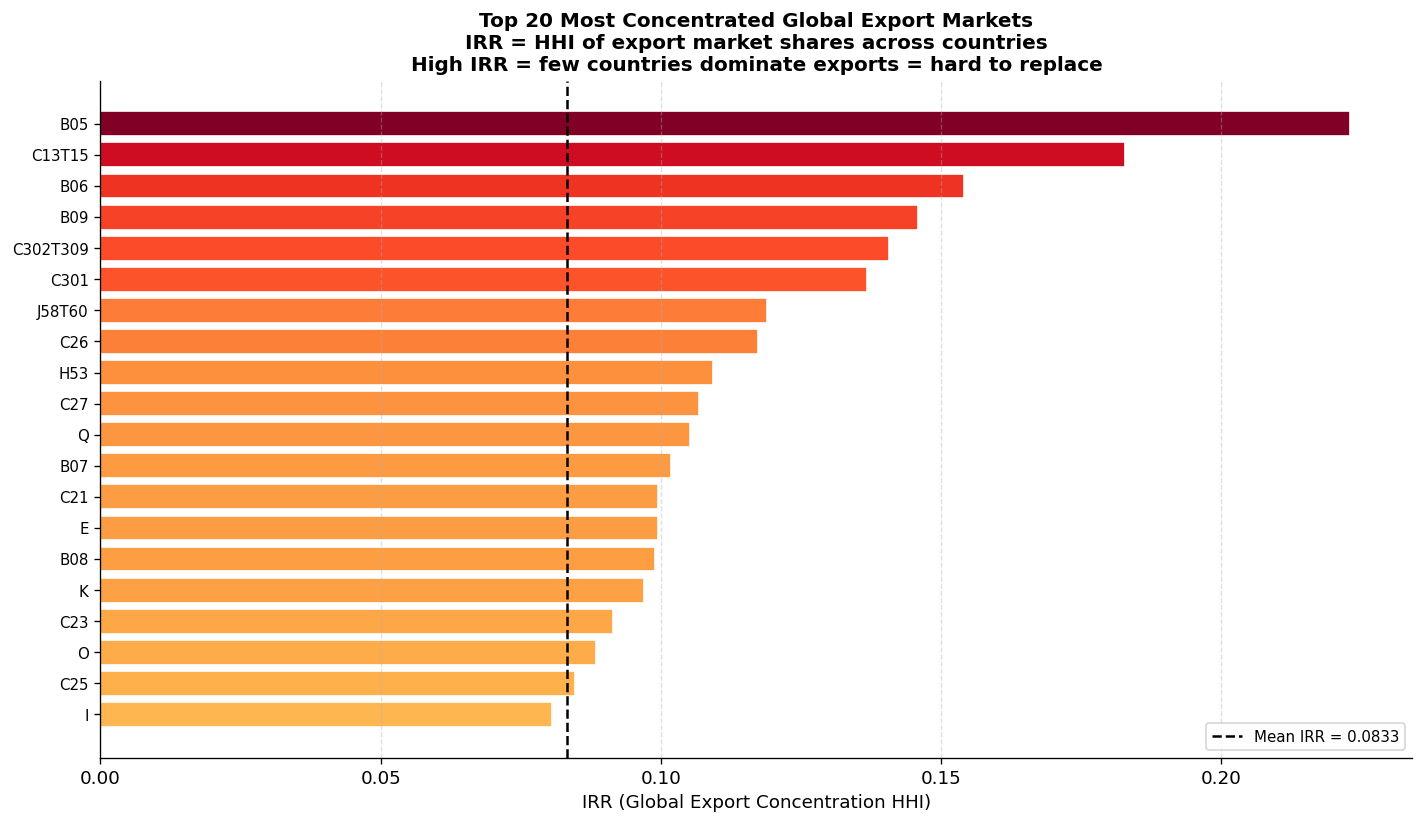

Top 20 most concentrated export markets:
sector_code
B05         0.222951
C13T15      0.182886
B06         0.154113
B09         0.145945
C302T309    0.140728
C301        0.136797
J58T60      0.119016
C26         0.117303
H53         0.109292
C27         0.106891
Q           0.105186
B07         0.101891
C21         0.099562
E           0.099556
B08         0.098968
K           0.097075
C23         0.091528
O           0.088441
C25         0.084602
I           0.080624


In [5]:
# ── Top 20 most concentrated export markets ───────────────────────────────
top_irr = irr_by_sector.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 7))
colors  = plt.cm.YlOrRd(top_irr.values / top_irr.max())
ax.barh(range(len(top_irr)), top_irr.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(top_irr)))
ax.set_yticklabels(top_irr.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('IRR (Global Export Concentration HHI)', fontsize=11)
ax.set_title(
    'Top 20 Most Concentrated Global Export Markets\n'
    'IRR = HHI of export market shares across countries\n'
    'High IRR = few countries dominate exports = hard to replace',
    fontsize=12, fontweight='bold'
)
ax.axvline(irr_by_sector.mean(), color='black', linestyle='--',
           linewidth=1.5, label=f'Mean IRR = {irr_by_sector.mean():.4f}')
ax.legend(fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/vj_eda_top_irr.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 20 most concentrated export markets:')
print(top_irr.to_string())

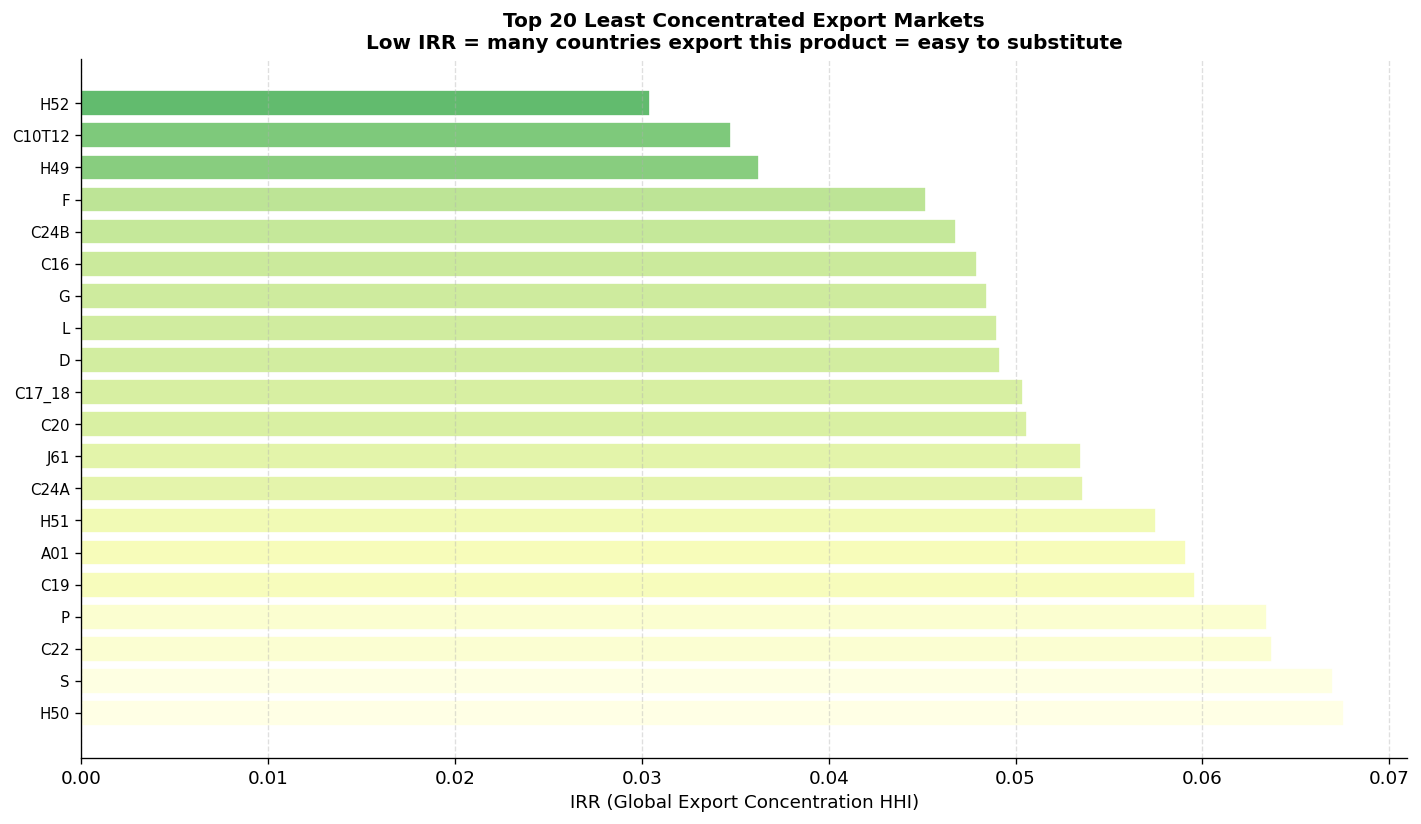

Bottom 20 least concentrated:
sector_code
H52       0.030460
C10T12    0.034768
H49       0.036281
F         0.045223
C24B      0.046819
C16       0.047947
G         0.048486
L         0.049012
D         0.049154
C17_18    0.050411
C20       0.050631
J61       0.053520
C24A      0.053606
H51       0.057527
A01       0.059143
C19       0.059617
P         0.063476
C22       0.063731
S         0.066971
H50       0.067590


In [6]:
# ── Bottom 20 least concentrated (most substitutable) ────────────────────
bottom_irr = irr_by_sector.sort_values(ascending=True).head(20)

fig, ax = plt.subplots(figsize=(12, 7))
colors  = plt.cm.YlGn(1 - bottom_irr.values / bottom_irr.max())
ax.barh(range(len(bottom_irr)), bottom_irr.values,
        color=colors, edgecolor='white')
ax.set_yticks(range(len(bottom_irr)))
ax.set_yticklabels(bottom_irr.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('IRR (Global Export Concentration HHI)', fontsize=11)
ax.set_title(
    'Top 20 Least Concentrated Export Markets\n'
    'Low IRR = many countries export this product = easy to substitute',
    fontsize=12, fontweight='bold'
)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/vj_eda_bottom_irr.png', dpi=150, bbox_inches='tight')
plt.show()

print('Bottom 20 least concentrated:')
print(bottom_irr.to_string())

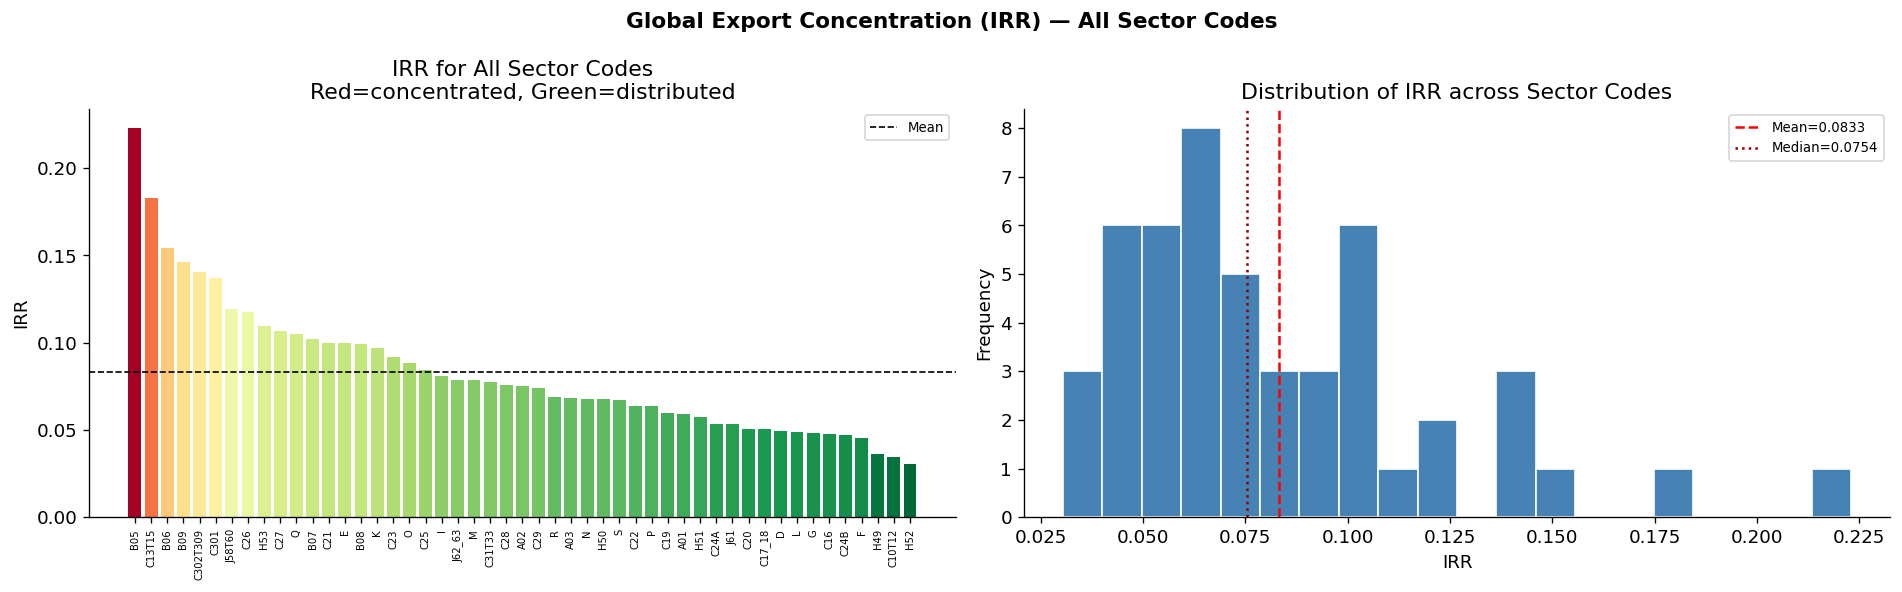

IRR statistics across 49 sector codes:
count    49.000000
mean      0.083315
std       0.038995
min       0.030460
25%       0.053606
50%       0.075423
75%       0.099562
max       0.222951


In [7]:
# ── Full IRR distribution across ALL sector codes ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# All sector codes sorted
irr_sorted = irr_by_sector.sort_values(ascending=False)
norm       = (irr_sorted.values - irr_sorted.min()) / (irr_sorted.max() - irr_sorted.min())
colors     = plt.cm.RdYlGn_r(norm)

axes[0].bar(range(len(irr_sorted)), irr_sorted.values,
            color=colors, edgecolor='none', width=0.8)
axes[0].set_xticks(range(len(irr_sorted)))
axes[0].set_xticklabels(irr_sorted.index, rotation=90, fontsize=6)
axes[0].set_ylabel('IRR')
axes[0].set_title('IRR for All Sector Codes\nRed=concentrated, Green=distributed')
axes[0].axhline(irr_by_sector.mean(), color='black',
                linestyle='--', linewidth=1, label='Mean')
axes[0].legend(fontsize=8)

axes[1].hist(irr_by_sector.values, bins=20,
             color='steelblue', edgecolor='white')
axes[1].axvline(irr_by_sector.mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean={irr_by_sector.mean():.4f}')
axes[1].axvline(irr_by_sector.median(), color='darkred', linestyle=':',
                linewidth=1.5, label=f'Median={irr_by_sector.median():.4f}')
axes[1].set_xlabel('IRR')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of IRR across Sector Codes')
axes[1].legend(fontsize=8)

plt.suptitle('Global Export Concentration (IRR) — All Sector Codes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/vj_eda_irr_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'IRR statistics across {len(irr_by_sector)} sector codes:')
print(irr_by_sector.describe().to_string())

---
## Section 2 — Input Distribution Sanity Check
Verify w_ij is correctly computed before it enters V_j.

Input distribution column sums:
  Min (nonzero) : 1.000000
  Max           : 1.000000
  Sectors summing to ~1.0 : 3928


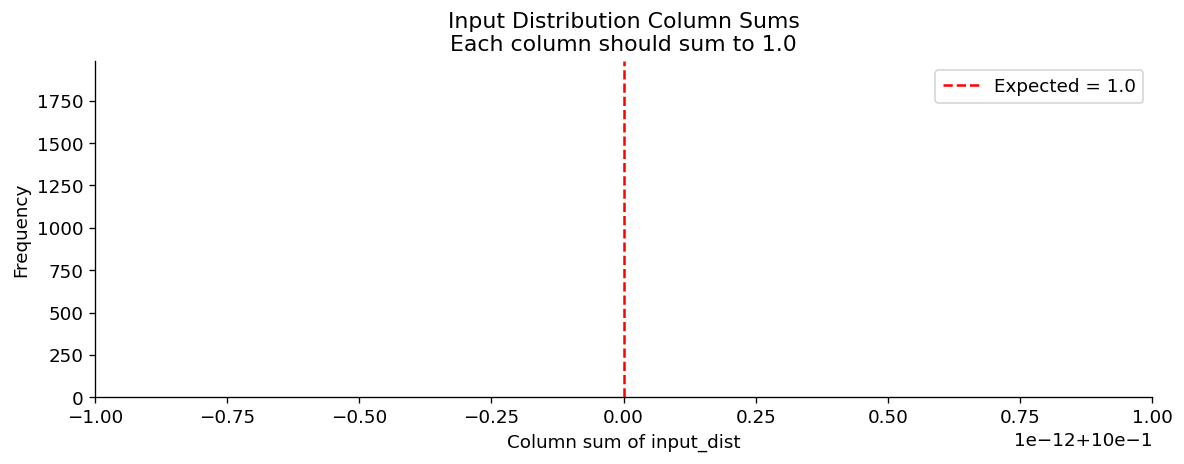

In [11]:
# Column sums should all be 1.0 (j's input budget fully allocated)
col_sums = input_dist.sum(axis=0)

print(f'Input distribution column sums:')
print(f'  Min (nonzero) : {col_sums[col_sums>0].min():.6f}')
print(f'  Max           : {col_sums.max():.6f}')
print(f'  Sectors summing to ~1.0 : {((col_sums-1).abs()<1e-6).sum()}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(col_sums[col_sums > 0], bins=5,
        color='steelblue', edgecolor='none')
ax.axvline(1.0, color='red', linestyle='--',
           linewidth=1.5, label='Expected = 1.0')
ax.set_xlabel('Column sum of input_dist')
ax.set_ylabel('Frequency')
ax.set_title('Input Distribution Column Sums\n'
             'Each column should sum to 1.0')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/vj_eda_colsums.png', dpi=150, bbox_inches='tight')
plt.show()

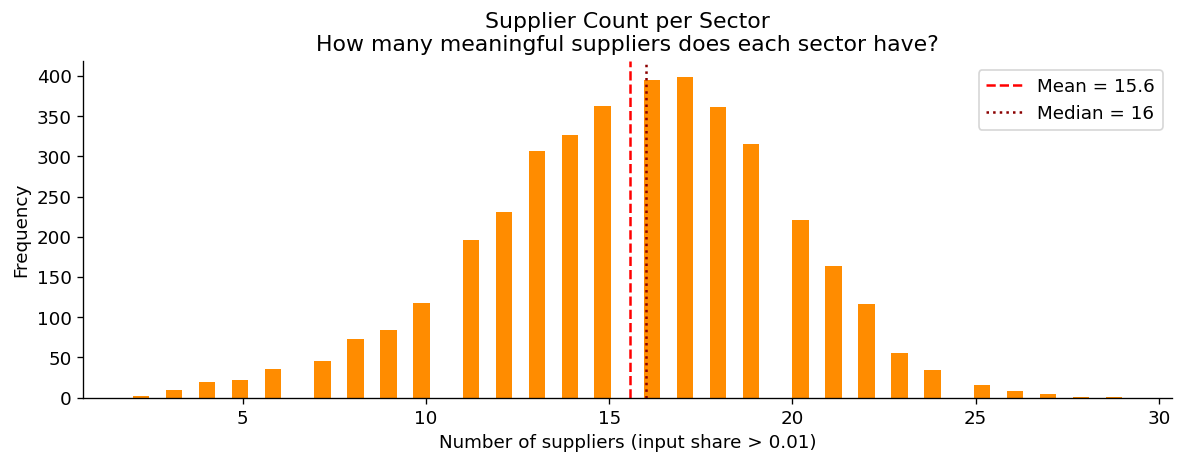

Supplier count (threshold=0.01):
count    3928.000000
mean       15.575102
std         4.049913
min         2.000000
25%        13.000000
50%        16.000000
75%        18.000000
max        29.000000


In [12]:
# How many meaningful suppliers does a typical sector have?
threshold       = 0.01
supplier_counts = (input_dist >= threshold).sum(axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(supplier_counts, bins=60, color='darkorange', edgecolor='none')
ax.axvline(supplier_counts.mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Mean = {supplier_counts.mean():.1f}')
ax.axvline(supplier_counts.median(), color='darkred', linestyle=':',
           linewidth=1.5, label=f'Median = {supplier_counts.median():.0f}')
ax.set_xlabel(f'Number of suppliers (input share > {threshold})')
ax.set_ylabel('Frequency')
ax.set_title('Supplier Count per Sector\n'
             'How many meaningful suppliers does each sector have?')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/vj_eda_supplier_counts.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Supplier count (threshold={threshold}):')
print(supplier_counts.describe().to_string())

---
## Section 3 — V_j Distribution
How is upstream vulnerability distributed across all 3928 sectors?

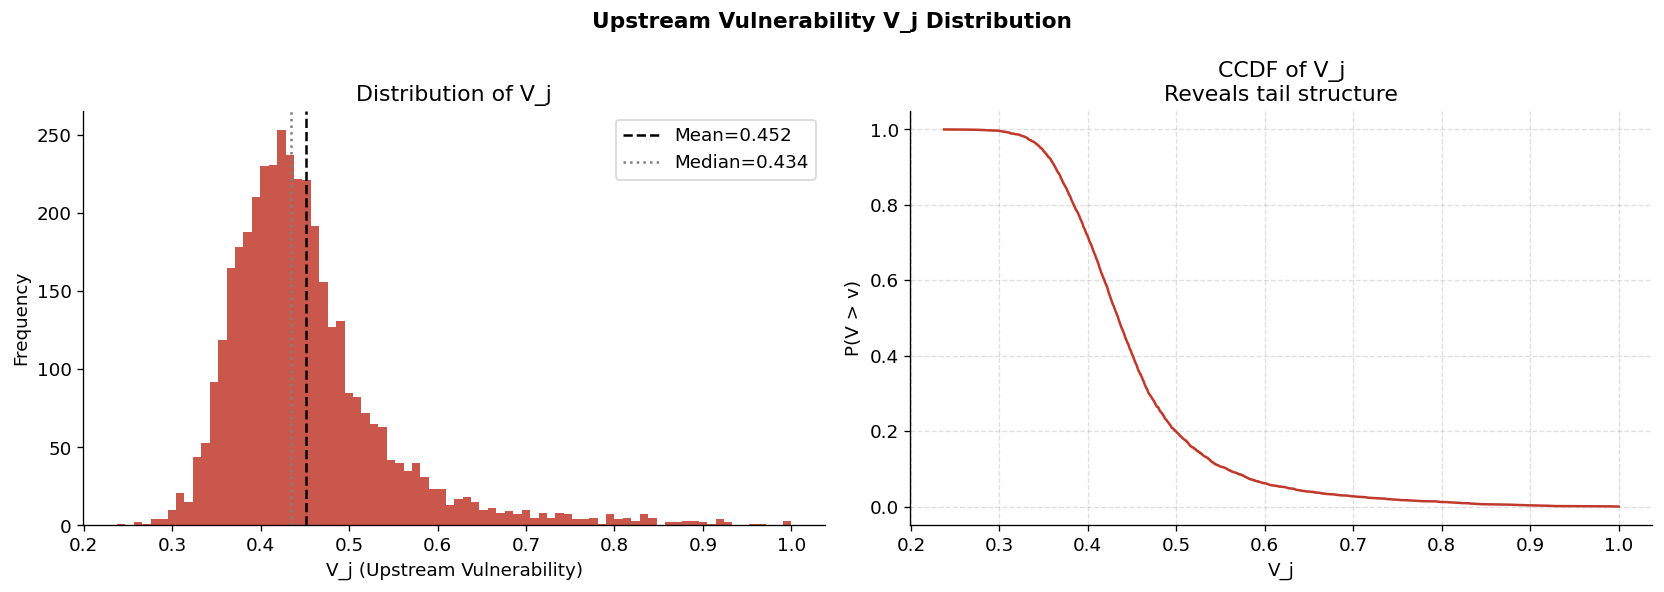

V_j statistics:
count    3928.000000
mean        0.451601
std         0.091896
min         0.237673
25%         0.394013
50%         0.434380
75%         0.482965
max         1.000000


In [13]:
# ── V_j distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['V_j'], bins=80, color='#c0392b',
             edgecolor='none', alpha=0.85)
axes[0].axvline(df['V_j'].mean(), color='black', linestyle='--',
                linewidth=1.5, label=f'Mean={df["V_j"].mean():.3f}')
axes[0].axvline(df['V_j'].median(), color='gray', linestyle=':',
                linewidth=1.5, label=f'Median={df["V_j"].median():.3f}')
axes[0].set_xlabel('V_j (Upstream Vulnerability)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of V_j')
axes[0].legend()

# CCDF
sorted_v = np.sort(df['V_j'].values)
ccdf     = 1 - np.arange(1, len(sorted_v)+1) / len(sorted_v)
axes[1].plot(sorted_v, ccdf, color='#c0392b', linewidth=1.5)
axes[1].set_xlabel('V_j')
axes[1].set_ylabel('P(V > v)')
axes[1].set_title('CCDF of V_j\nReveals tail structure')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Upstream Vulnerability V_j Distribution',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/vj_eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('V_j statistics:')
print(df['V_j'].describe().to_string())

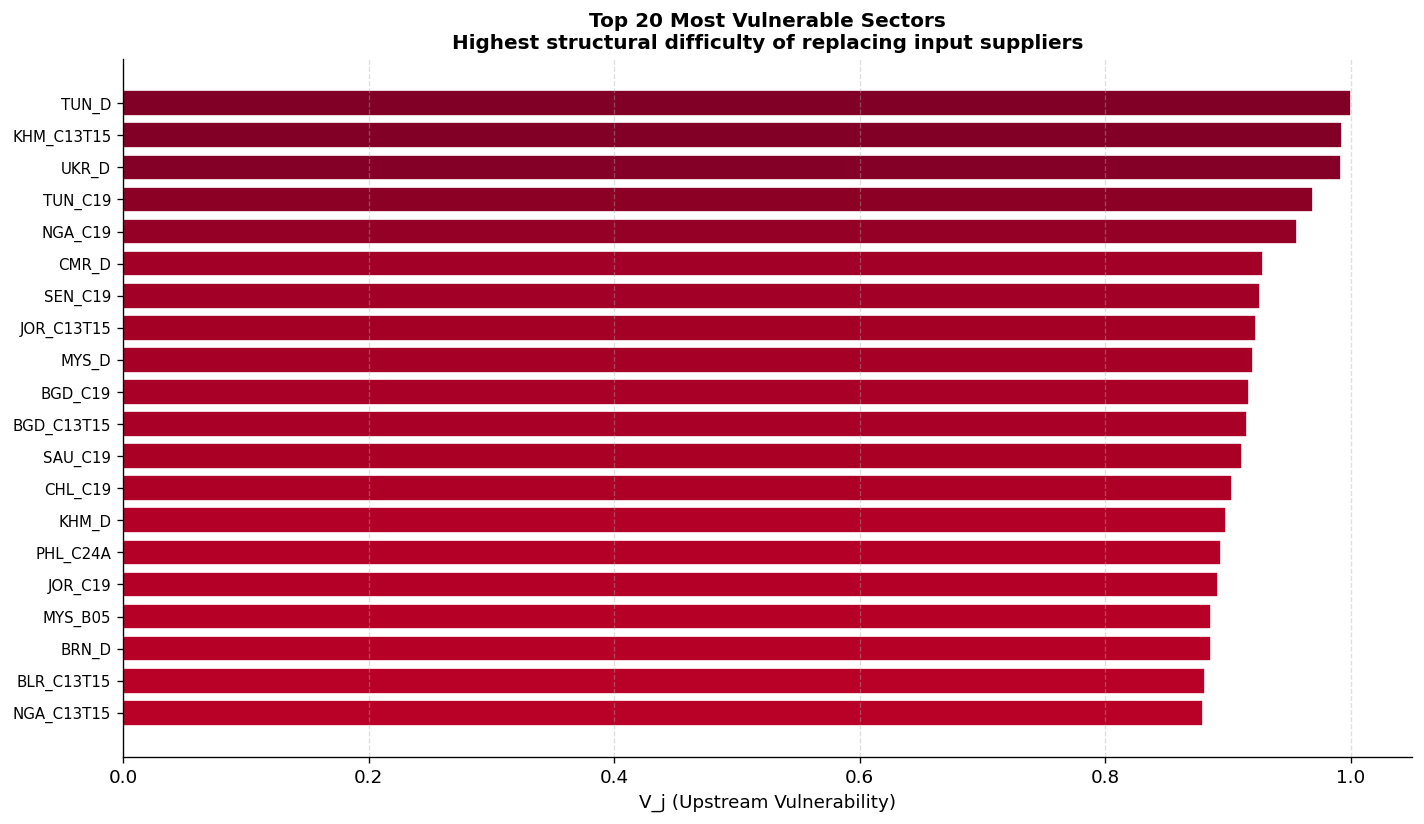

Top 20 most vulnerable:
      node country sector      V_j      IRR
     TUN_D     TUN      D 1.000000 0.049154
KHM_C13T15     KHM C13T15 0.992754 0.182886
     UKR_D     UKR      D 0.991932 0.049154
   TUN_C19     TUN    C19 0.969275 0.059617
   NGA_C19     NGA    C19 0.956028 0.059617
     CMR_D     CMR      D 0.928704 0.049154
   SEN_C19     SEN    C19 0.926037 0.059617
JOR_C13T15     JOR C13T15 0.922427 0.182886
     MYS_D     MYS      D 0.920582 0.049154
   BGD_C19     BGD    C19 0.917062 0.059617
BGD_C13T15     BGD C13T15 0.915525 0.182886
   SAU_C19     SAU    C19 0.911237 0.059617
   CHL_C19     CHL    C19 0.903241 0.059617
     KHM_D     KHM      D 0.897822 0.049154
  PHL_C24A     PHL   C24A 0.893807 0.053606
   JOR_C19     JOR    C19 0.891374 0.059617
   MYS_B05     MYS    B05 0.886173 0.222951
     BRN_D     BRN      D 0.885601 0.049154
BLR_C13T15     BLR C13T15 0.880836 0.182886
NGA_C13T15     NGA C13T15 0.879478 0.182886


In [14]:
# ── Top 20 most vulnerable sectors ───────────────────────────────────────
top_vj = df.nlargest(20, 'V_j')[['node','country','sector','V_j','IRR']]

fig, ax = plt.subplots(figsize=(12, 7))
colors  = plt.cm.YlOrRd(top_vj['V_j'].values / top_vj['V_j'].max())
ax.barh(range(len(top_vj)), top_vj['V_j'].values,
        color=colors, edgecolor='white')
ax.set_yticks(range(len(top_vj)))
ax.set_yticklabels(top_vj['node'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('V_j (Upstream Vulnerability)', fontsize=11)
ax.set_title(
    'Top 20 Most Vulnerable Sectors\n'
    'Highest structural difficulty of replacing input suppliers',
    fontsize=12, fontweight='bold'
)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/vj_eda_top_vulnerable.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 20 most vulnerable:')
print(top_vj.to_string(index=False))

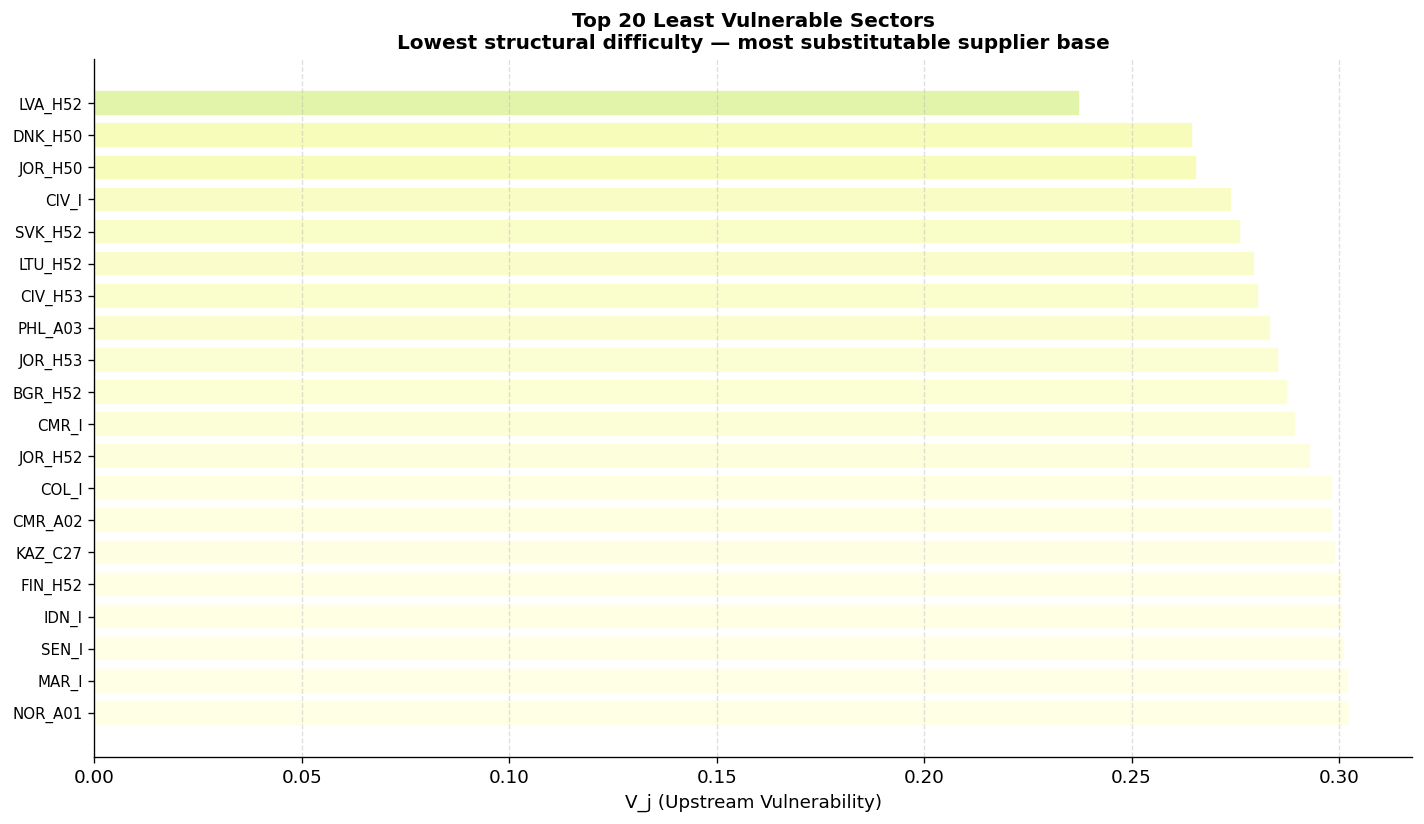

In [15]:
# ── Top 20 least vulnerable ───────────────────────────────────────────────
bottom_vj = df.nsmallest(20, 'V_j')[['node','country','sector','V_j','IRR']]

fig, ax = plt.subplots(figsize=(12, 7))
colors  = plt.cm.YlGn(1 - bottom_vj['V_j'].values / bottom_vj['V_j'].max())
ax.barh(range(len(bottom_vj)), bottom_vj['V_j'].values,
        color=colors, edgecolor='white')
ax.set_yticks(range(len(bottom_vj)))
ax.set_yticklabels(bottom_vj['node'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('V_j (Upstream Vulnerability)', fontsize=11)
ax.set_title(
    'Top 20 Least Vulnerable Sectors\n'
    'Lowest structural difficulty — most substitutable supplier base',
    fontsize=12, fontweight='bold'
)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/vj_eda_bottom_vulnerable.png', dpi=150, bbox_inches='tight')
plt.show()

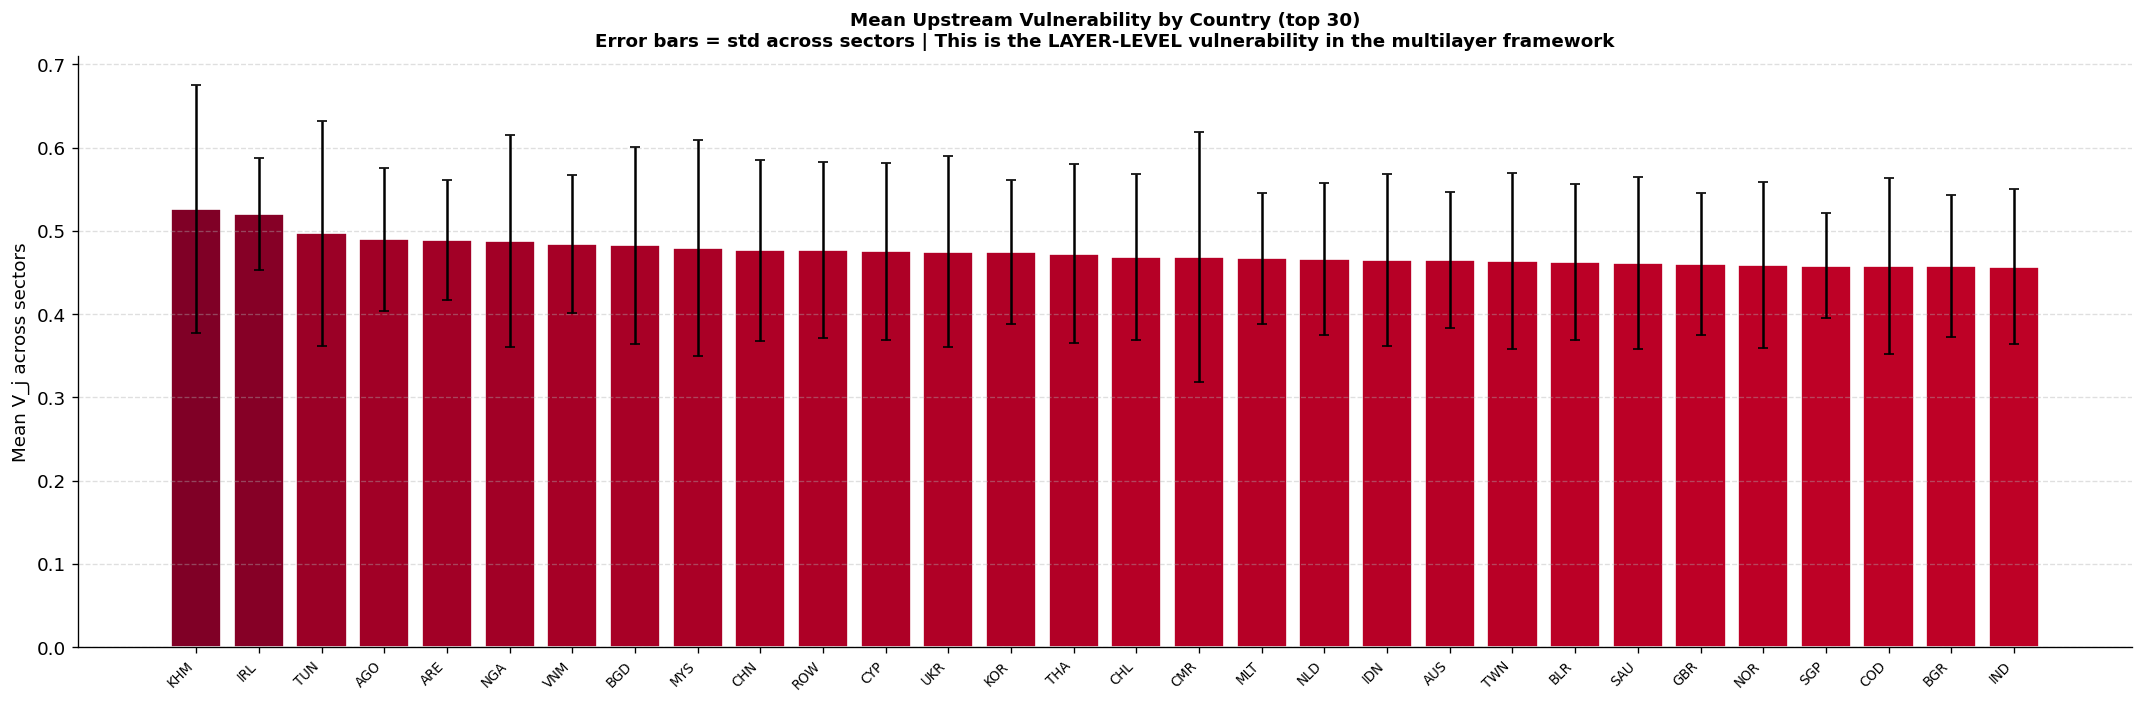

Top 15 most vulnerable countries (mean V_j):
             mean    median       std
country                              
KHM      0.526490  0.509005  0.149236
IRL      0.520186  0.504491  0.067184
TUN      0.496975  0.475896  0.135343
AGO      0.489964  0.464478  0.085928
ARE      0.489233  0.466433  0.072051
NGA      0.488262  0.458318  0.127197
VNM      0.483907  0.474972  0.082680
BGD      0.482561  0.453744  0.118255
MYS      0.479881  0.439662  0.129724
CHN      0.476643  0.452828  0.108576
ROW      0.476640  0.445886  0.105580
CYP      0.475275  0.449387  0.106267
UKR      0.475019  0.462850  0.114403
KOR      0.474374  0.469017  0.086366
THA      0.472808  0.454779  0.107721


In [16]:
# ── V_j by country — layer-level vulnerability ────────────────────────────
# This is the LAYER-LEVEL view in your multilayer framework
country_vj = (
    df.groupby('country')['V_j']
    .agg(['mean','median','std'])
    .sort_values('mean', ascending=False)
)

fig, ax = plt.subplots(figsize=(18, 6))
top30   = country_vj.head(30)
ax.bar(
    range(len(top30)), top30['mean'].values,
    yerr=top30['std'].values,
    color=plt.cm.YlOrRd(top30['mean'].values / top30['mean'].max()),
    edgecolor='white', capsize=3
)
ax.set_xticks(range(len(top30)))
ax.set_xticklabels(top30.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean V_j across sectors', fontsize=11)
ax.set_title(
    'Mean Upstream Vulnerability by Country (top 30)\n'
    'Error bars = std across sectors | '
    'This is the LAYER-LEVEL vulnerability in the multilayer framework',
    fontsize=11, fontweight='bold'
)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/vj_eda_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 15 most vulnerable countries (mean V_j):')
print(country_vj.head(15).to_string())

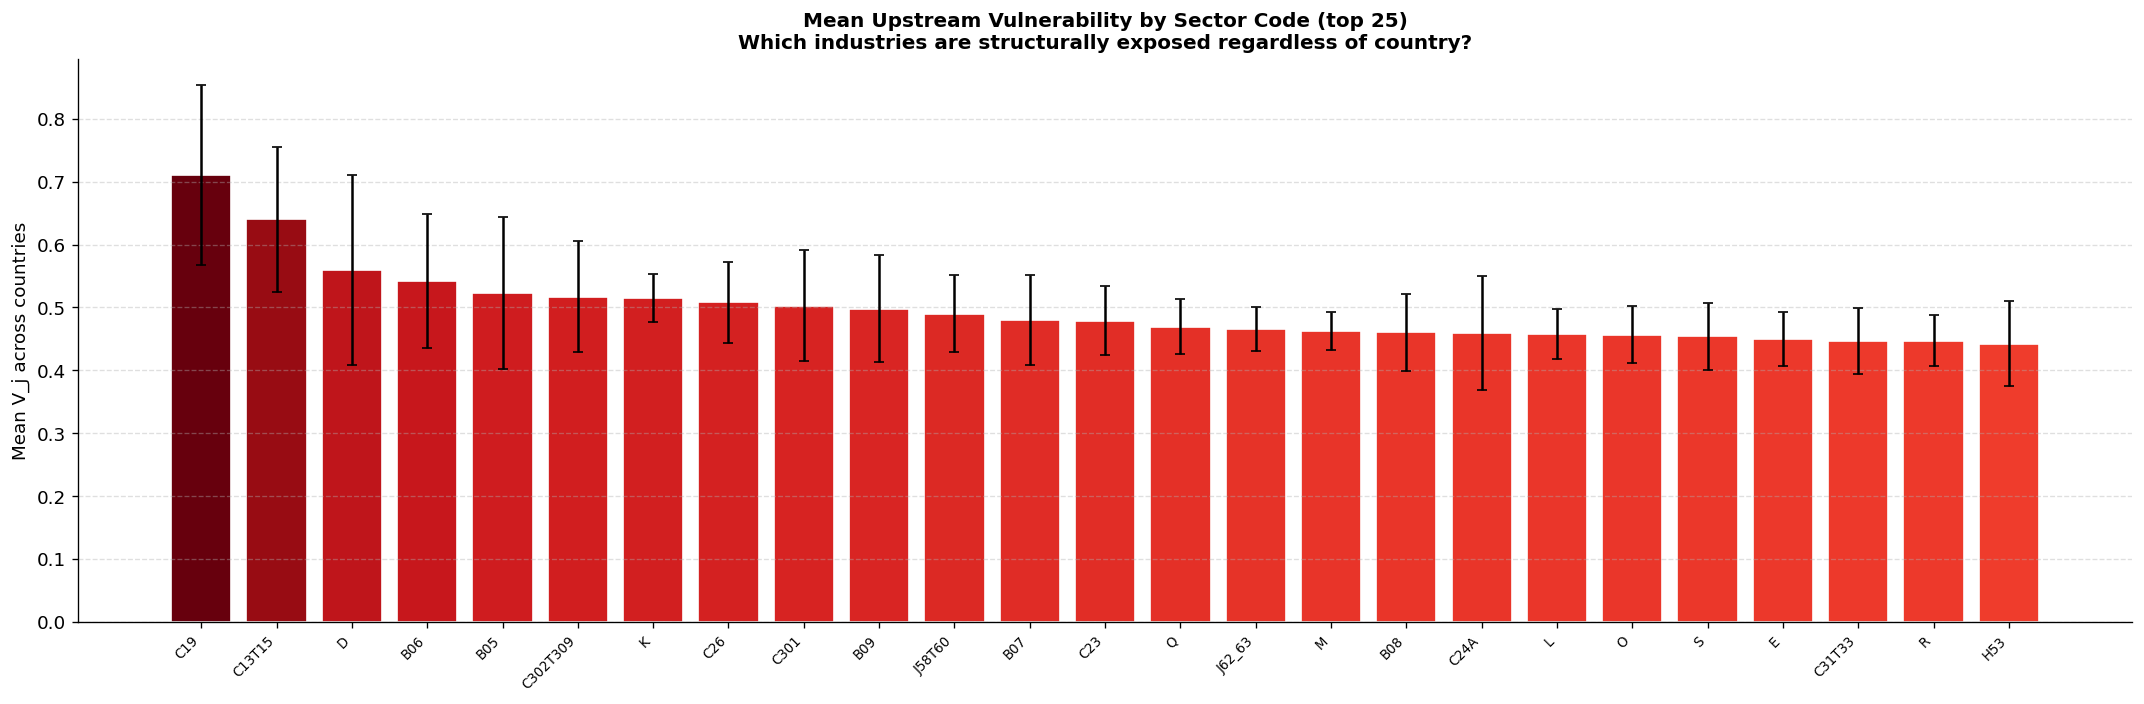

In [17]:
# ── V_j by sector code — which industries are structurally exposed? ────────
sector_vj = (
    df.groupby('sector')['V_j']
    .agg(['mean','std'])
    .sort_values('mean', ascending=False)
)

fig, ax = plt.subplots(figsize=(18, 6))
top25   = sector_vj.head(25)
ax.bar(
    range(len(top25)), top25['mean'].values,
    yerr=top25['std'].values,
    color=plt.cm.Reds(top25['mean'].values / top25['mean'].max()),
    edgecolor='white', capsize=3
)
ax.set_xticks(range(len(top25)))
ax.set_xticklabels(top25.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean V_j across countries', fontsize=11)
ax.set_title(
    'Mean Upstream Vulnerability by Sector Code (top 25)\n'
    'Which industries are structurally exposed regardless of country?',
    fontsize=12, fontweight='bold'
)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/vj_eda_by_sector.png', dpi=150, bbox_inches='tight')
plt.show()

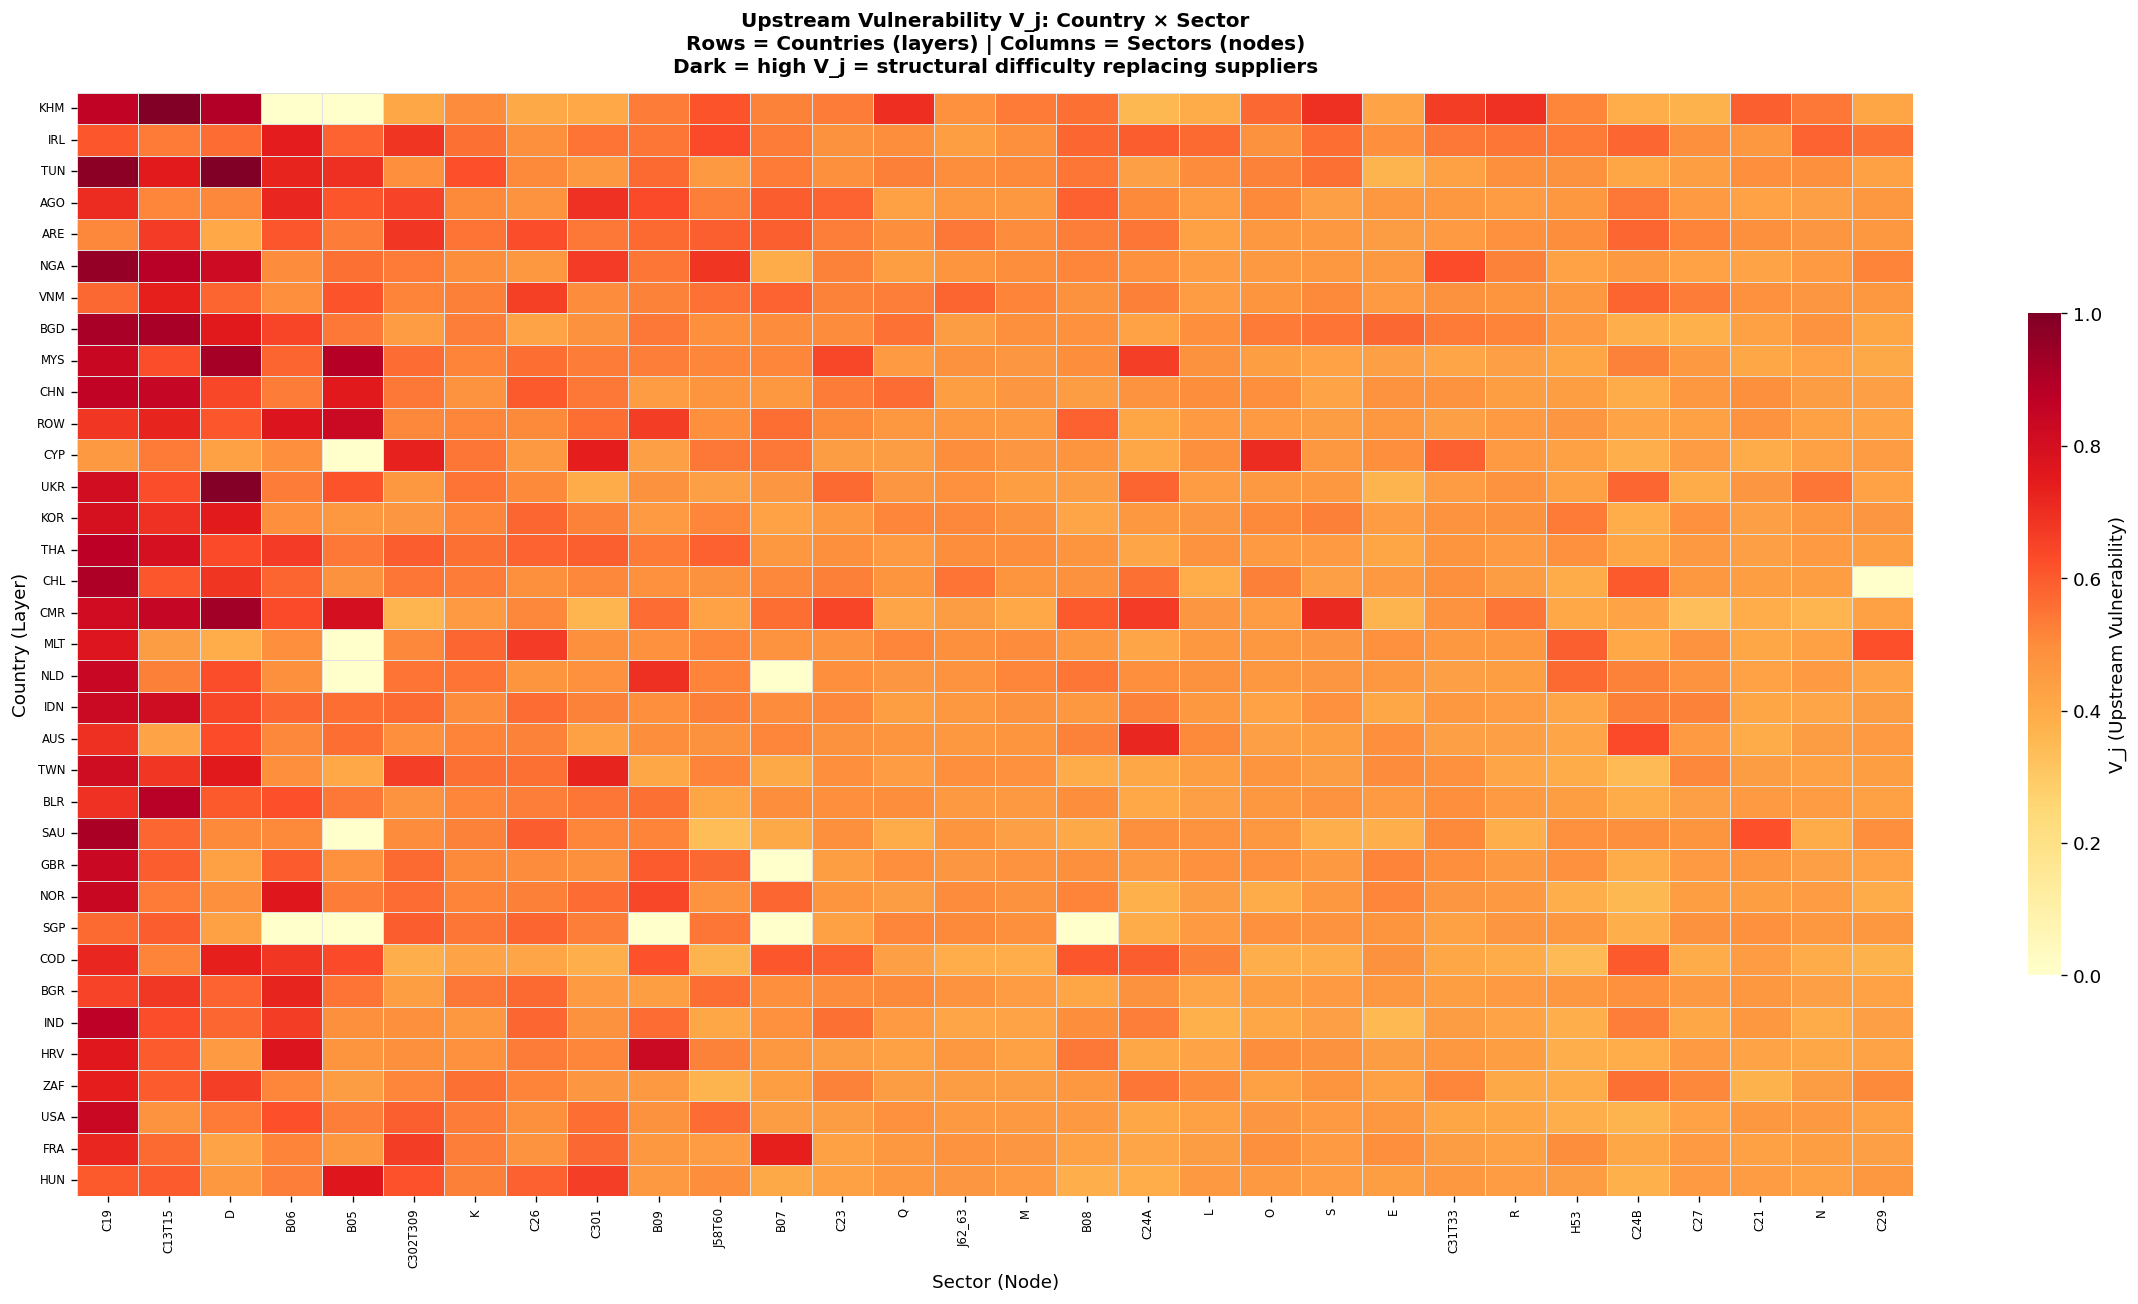

In [18]:
# ── Heatmap: V_j by country x sector — the multilayer view ───────────────
# Rows = country layers, Columns = sector nodes
# This is the first visual of your multilayer structure
pivot_vj = df.pivot_table(
    index='country', columns='sector',
    values='V_j', aggfunc='mean'
).fillna(0)

top_sec  = sector_vj.head(30).index
top_ctry = country_vj.head(35).index
pivot_sub = pivot_vj.loc[top_ctry, top_sec]

fig, ax = plt.subplots(figsize=(20, 11))
sns.heatmap(
    pivot_sub, ax=ax,
    cmap='YlOrRd',
    linewidths=0.3, linecolor='#e0e0e0',
    cbar_kws={'label':'V_j (Upstream Vulnerability)','shrink':0.6},
    xticklabels=True, yticklabels=True,
)
ax.set_title(
    'Upstream Vulnerability V_j: Country × Sector\n'
    'Rows = Countries (layers) | Columns = Sectors (nodes)\n'
    'Dark = high V_j = structural difficulty replacing suppliers',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xlabel('Sector (Node)', fontsize=11)
ax.set_ylabel('Country (Layer)', fontsize=11)
ax.tick_params(axis='x', labelsize=7, rotation=90)
ax.tick_params(axis='y', labelsize=7, rotation=0)
plt.tight_layout()
plt.savefig('../outputs/vj_eda_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4 — V_j vs Degree Measures

**Key question**: Does V_j capture something different from simple degree?

If V_j correlates perfectly with in-degree, it adds no information beyond what the EDA already showed.
Low-to-moderate correlation confirms V_j isolates network effects that degree cannot capture.

In [19]:
# Compute degree measures using same threshold as EDA
tau            = 0.01
adj            = (input_dist >= tau)
in_degree      = adj.sum(axis=0)   # number of meaningful suppliers
out_degree     = adj.sum(axis=1)   # number of sectors j supplies to

df['in_degree']  = in_degree.reindex(df.index).values
df['out_degree'] = out_degree.reindex(df.index).values

corr_in  = df['V_j'].corr(df['in_degree'])
corr_out = df['V_j'].corr(df['out_degree'])
corr_irr = df['V_j'].corr(df['IRR'])

print(f'Correlations with V_j:')
print(f'  vs in_degree  : {corr_in:.4f}')
print(f'  vs out_degree : {corr_out:.4f}')
print(f'  vs IRR        : {corr_irr:.4f}')

Correlations with V_j:
  vs in_degree  : -0.0707
  vs out_degree : 0.0758
  vs IRR        : 0.3942


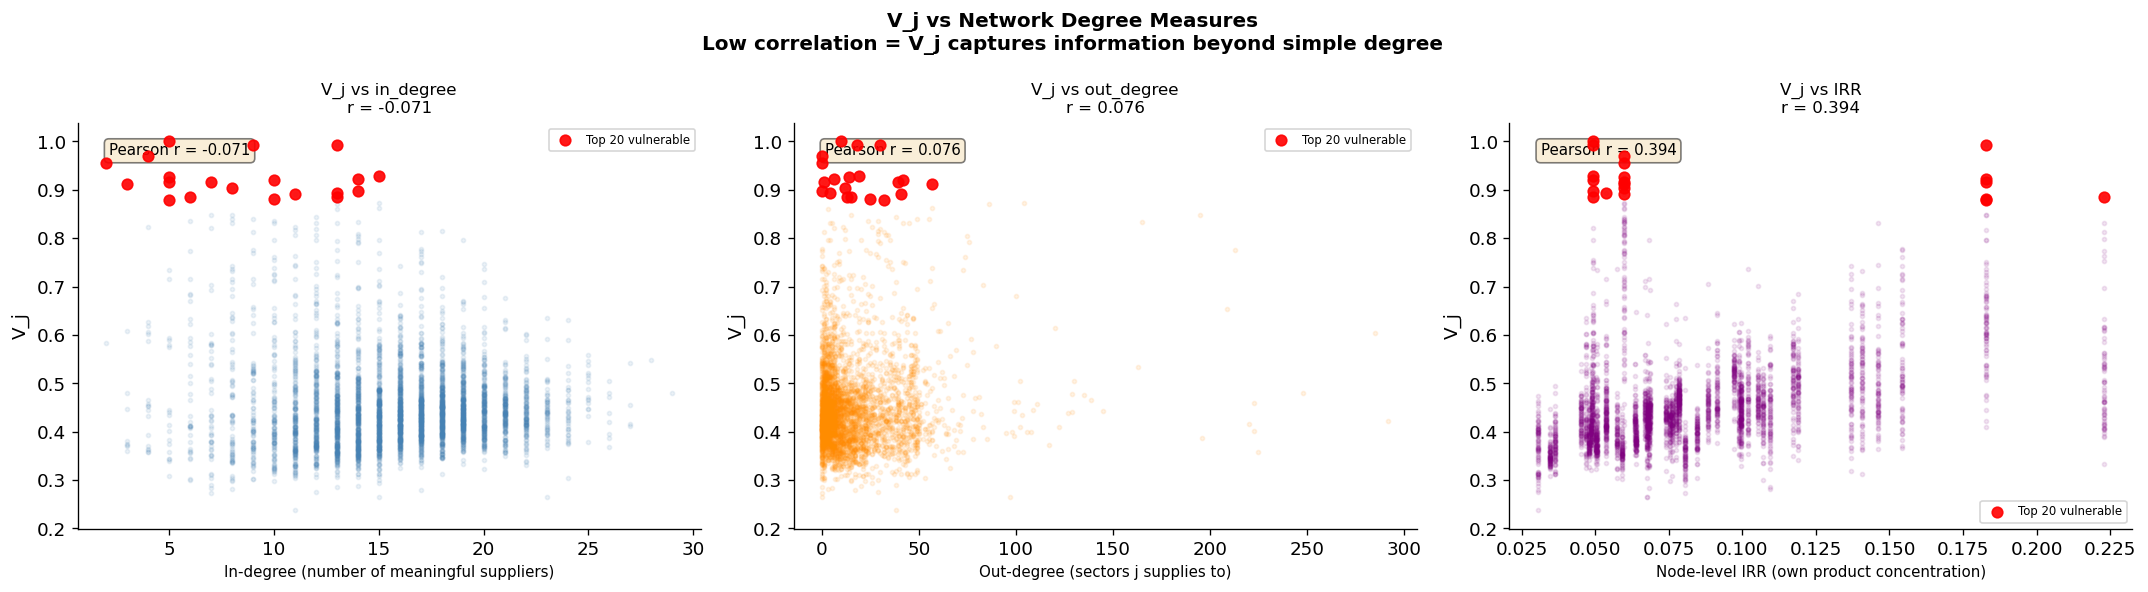


Interpretation:
  V_j vs in_degree  (r=-0.071): LOW correlation
  V_j is NOT redundant with in-degree — captures additional info ✓


In [20]:
# ── Scatter plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top20     = df.nlargest(20, 'V_j')

for ax, xcol, xlabel, corr, color in [
    (axes[0], 'in_degree',
     'In-degree (number of meaningful suppliers)', corr_in,  'steelblue'),
    (axes[1], 'out_degree',
     'Out-degree (sectors j supplies to)',          corr_out, 'darkorange'),
    (axes[2], 'IRR',
     'Node-level IRR (own product concentration)',  corr_irr, 'purple'),
]:
    ax.scatter(df[xcol], df['V_j'],
               alpha=0.1, s=6, color=color)
    ax.scatter(top20[xcol], top20['V_j'],
               alpha=0.9, s=40, color='red',
               zorder=5, label='Top 20 vulnerable')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('V_j')
    ax.set_title(f'V_j vs {xcol}\nr = {corr:.3f}', fontsize=10)
    ax.text(0.05, 0.95, f'Pearson r = {corr:.3f}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.legend(fontsize=7)

plt.suptitle(
    'V_j vs Network Degree Measures\n'
    'Low correlation = V_j captures information beyond simple degree',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../outputs/vj_eda_vs_degree.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretation
print('\nInterpretation:')
if abs(corr_in) < 0.5:
    print(f'  V_j vs in_degree  (r={corr_in:.3f}): LOW correlation')
    print(f'  V_j is NOT redundant with in-degree — captures additional info ✓')
else:
    print(f'  V_j vs in_degree  (r={corr_in:.3f}): MODERATE/HIGH correlation')
    print(f'  Review whether V_j adds enough beyond degree')

In [21]:
# ── The most interesting nodes: divergence between degree and V_j ──────────
# HIGH in-degree but HIGH V_j = many suppliers but all from concentrated markets
# This is what V_j reveals that degree CANNOT

high_deg_high_v = df[
    (df['in_degree'] > df['in_degree'].quantile(0.75)) &
    (df['V_j']       > df['V_j'].quantile(0.75))
].nlargest(15, 'V_j')

print('Sectors with HIGH in-degree AND HIGH V_j:')
print('(Appear diversified by count but exposed to concentrated markets)')
print(high_deg_high_v[['node','country','sector',
                        'in_degree','V_j']].to_string(index=False))
print()

# LOW in-degree AND LOW V_j = few suppliers from distributed markets
low_deg_low_v = df[
    (df['in_degree'] < df['in_degree'].quantile(0.25)) &
    (df['V_j']       < df['V_j'].quantile(0.25))
].nsmallest(15, 'V_j')

print('Sectors with LOW in-degree AND LOW V_j:')
print('(Few suppliers but from distributed markets — structurally resilient)')
print(low_deg_low_v[['node','country','sector',
                      'in_degree','V_j']].to_string(index=False))

Sectors with HIGH in-degree AND HIGH V_j:
(Appear diversified by count but exposed to concentrated markets)
      node country sector  in_degree      V_j
MAR_C13T15     MAR C13T15         19 0.796750
TUN_C13T15     TUN C13T15         20 0.747371
   FRA_B07     FRA    B07         20 0.736880
ISL_C13T15     ISL C13T15         20 0.708929
BGR_C13T15     BGR C13T15         20 0.678686
   POL_C19     POL    C19         21 0.676938
ARE_C13T15     ARE C13T15         19 0.669719
LAO_C13T15     LAO C13T15         19 0.668072
  MYS_C24A     MYS   C24A         19 0.663142
     JPN_D     JPN      D         20 0.654825
POL_C13T15     POL C13T15         19 0.653464
   DEU_C19     DEU    C19         23 0.635272
     LUX_D     LUX      D         24 0.630606
BEL_C13T15     BEL C13T15         21 0.630051
     NLD_D     NLD      D         21 0.626907

Sectors with LOW in-degree AND LOW V_j:
(Few suppliers but from distributed markets — structurally resilient)
   node country sector  in_degree      V_j
LV

---
## Section 5 — Economic Validation

Do the V_j rankings make economic sense?

**Expected:**
- High V_j: small energy-importing countries, energy-intensive manufacturing
- Low V_j: transport services, large diversified economies' service sectors
- Country pattern: small open economies with concentrated import partners > large diversified

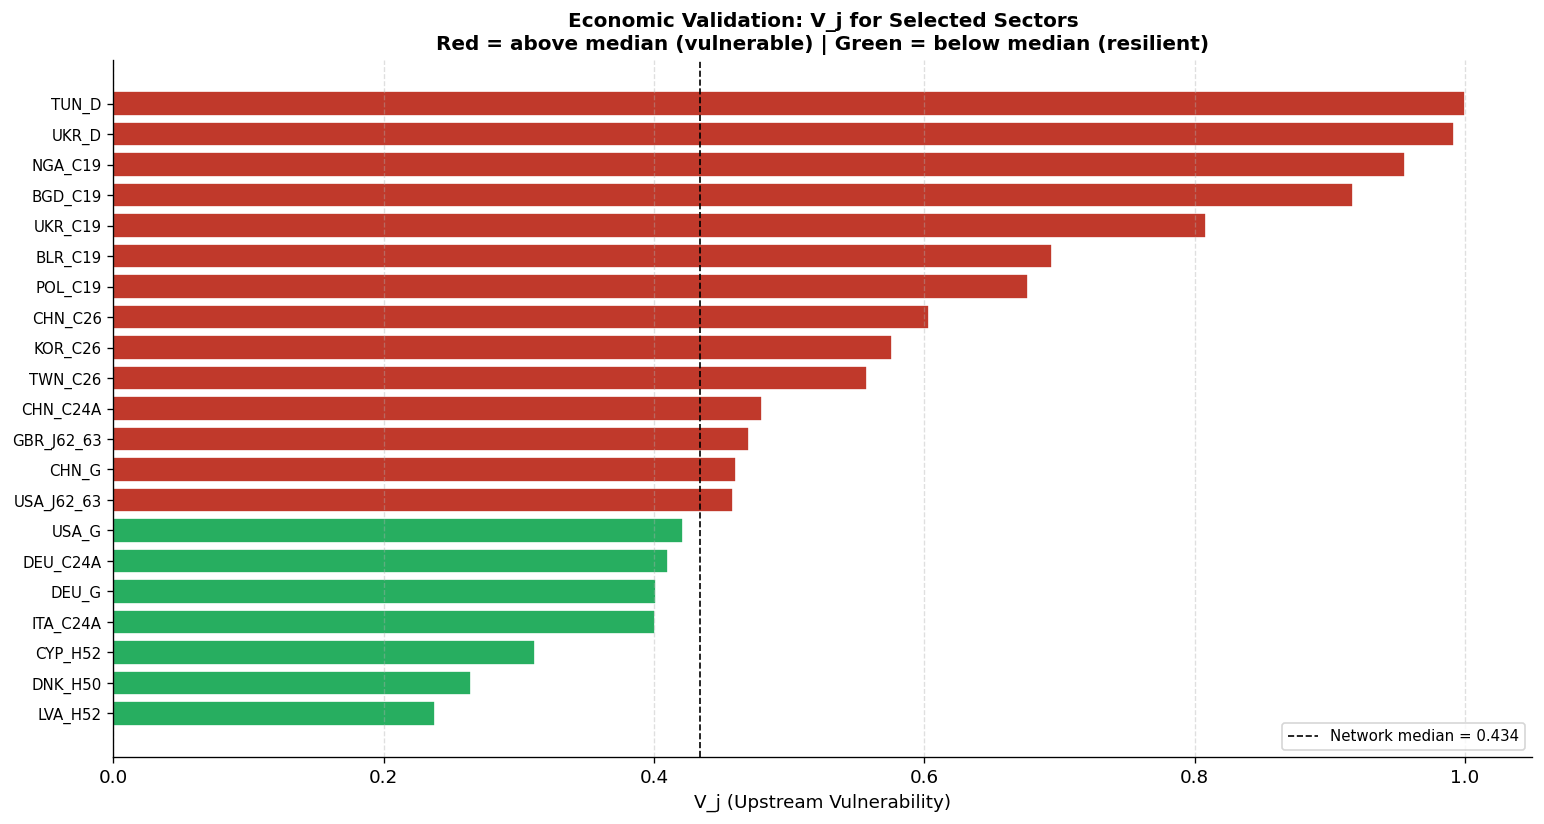

V_j for selected sectors:
           country  sector       V_j       IRR
V1                                            
TUN_D          TUN       D  1.000000  0.049154
UKR_D          UKR       D  0.991932  0.049154
NGA_C19        NGA     C19  0.956028  0.059617
BGD_C19        BGD     C19  0.917062  0.059617
UKR_C19        UKR     C19  0.808251  0.059617
BLR_C19        BLR     C19  0.694780  0.059617
POL_C19        POL     C19  0.676938  0.059617
CHN_C26        CHN     C26  0.603827  0.117303
KOR_C26        KOR     C26  0.576425  0.117303
TWN_C26        TWN     C26  0.557264  0.117303
CHN_C24A       CHN    C24A  0.480011  0.053606
GBR_J62_63     GBR  J62_63  0.470342  0.078638
CHN_G          CHN       G  0.460652  0.048486
USA_J62_63     USA  J62_63  0.458763  0.078638
USA_G          USA       G  0.421336  0.048486
DEU_C24A       DEU    C24A  0.410236  0.053606
DEU_G          DEU       G  0.401256  0.048486
ITA_C24A       ITA    C24A  0.400620  0.053606
CYP_H52        CYP     H52  0.3122

In [22]:
# ── V_j for economically interesting nodes ────────────────────────────────
interesting = [
    # Small energy-dependent countries — expect HIGH V_j
    'TUN_D',   'UKR_D',   'NGA_C19',  'BGD_C19',
    # Energy-intensive manufacturing in import-dependent countries
    'BLR_C19', 'UKR_C19', 'POL_C19',
    # Basic metals in large economies
    'DEU_C24A','ITA_C24A','CHN_C24A',
    # Semiconductors
    'CHN_C26', 'KOR_C26', 'TWN_C26',
    # Services in large economies — expect LOW V_j
    'USA_G',   'DEU_G',   'CHN_G',
    'USA_J62_63','GBR_J62_63',
    # Transport — expect LOW V_j
    'DNK_H50', 'CYP_H52', 'LVA_H52',
]

existing  = [n for n in interesting if n in df.index]
check_df  = df.loc[existing, ['country','sector','V_j','IRR']].copy()
check_df  = check_df.sort_values('V_j', ascending=False)
median_vj = df['V_j'].median()

fig, ax = plt.subplots(figsize=(13, 7))
colors  = ['#c0392b' if v > median_vj else '#27ae60'
           for v in check_df['V_j'].values]
ax.barh(range(len(check_df)), check_df['V_j'].values,
        color=colors, edgecolor='white')
ax.axvline(median_vj, color='black', linestyle='--', linewidth=1,
           label=f'Network median = {median_vj:.3f}')
ax.set_yticks(range(len(check_df)))
ax.set_yticklabels(check_df.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('V_j (Upstream Vulnerability)')
ax.set_title(
    'Economic Validation: V_j for Selected Sectors\n'
    'Red = above median (vulnerable) | Green = below median (resilient)',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/vj_eda_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print('V_j for selected sectors:')
print(check_df.to_string())

In [23]:
# ── Summary table for thesis ───────────────────────────────────────────────
print('=' * 60)
print('V_j EDA SUMMARY')
print('=' * 60)
print(f'Total sectors          : {len(df)}')
print(f'V_j range              : [{df["V_j"].min():.4f}, {df["V_j"].max():.4f}]')
print(f'V_j mean               : {df["V_j"].mean():.4f}')
print(f'V_j median             : {df["V_j"].median():.4f}')
print(f'Sectors V_j > 0.7      : {(df["V_j"]>0.7).sum()} ({100*(df["V_j"]>0.7).mean():.1f}%)')
print(f'Sectors V_j < 0.3      : {(df["V_j"]<0.3).sum()} ({100*(df["V_j"]<0.3).mean():.1f}%)')
print()
print(f'Most vulnerable        : {df["V_j"].idxmax()} (V_j={df["V_j"].max():.4f})')
print(f'Least vulnerable       : {df["V_j"].idxmin()} (V_j={df["V_j"].min():.4f})')
print()
print(f'Most vulnerable country  : {country_vj["mean"].idxmax()} '
      f'(mean V_j={country_vj["mean"].max():.4f})')
print(f'Least vulnerable country : {country_vj["mean"].idxmin()} '
      f'(mean V_j={country_vj["mean"].min():.4f})')
print()
print(f'Correlation V_j vs in_degree  : {corr_in:.4f}')
print(f'Correlation V_j vs out_degree : {corr_out:.4f}')
print(f'Correlation V_j vs IRR        : {corr_irr:.4f}')
print()
print('IRR Summary (sector codes):')
print(f'  Most concentrated  : {irr_by_sector.idxmax()} '
      f'(IRR={irr_by_sector.max():.4f})')
print(f'  Least concentrated : {irr_by_sector.idxmin()} '
      f'(IRR={irr_by_sector.min():.4f})')

V_j EDA SUMMARY
Total sectors          : 3928
V_j range              : [0.2377, 1.0000]
V_j mean               : 0.4516
V_j median             : 0.4344
Sectors V_j > 0.7      : 107 (2.7%)
Sectors V_j < 0.3      : 15 (0.4%)

Most vulnerable        : TUN_D (V_j=1.0000)
Least vulnerable       : LVA_H52 (V_j=0.2377)

Most vulnerable country  : KHM (mean V_j=0.5265)
Least vulnerable country : STP (mean V_j=0.3964)

Correlation V_j vs in_degree  : -0.0707
Correlation V_j vs out_degree : 0.0758
Correlation V_j vs IRR        : 0.3942

IRR Summary (sector codes):
  Most concentrated  : B05 (IRR=0.2230)
  Least concentrated : H52 (IRR=0.0305)


In [ ]:
from src.dynamics.compute_phi import compute_phi

phi_node, phi_country = compute_phi(
    lpi_path='../data/raw/lpi.xlsx',
    nodes=A.index,
    year=2018
)

print(phi_node.describe())

Computing phi_j: Institutional Absorption Capacity
Source: World Bank Logistics Performance Index (LPI)

[1/4] Loading LPI 2018 from ../data/raw/lpi.xlsx...
  LPI countries not mapped to ICIO (78): ['Qatar', 'Panama', 'Oman', 'Rwanda', 'Bahrain', 'Kuwait', 'Serbia', 'Kenya', 'Bosnia and Herzegovina', 'Paraguay', 'Benin', 'Montenegro', 'Mauritius', 'Lebanon', 'Macedonia, FYR', 'Uruguay', 'Maldives', 'Dominican Republic', 'Albania', 'Djibouti', 'Burkina Faso', 'Armenia', 'Honduras', 'Sri Lanka', 'Mali', 'Malawi', 'Uzbekistan', 'El Salvador', 'Uganda', 'Solomon Islands', 'Ghana', 'Comoros', 'Kyrgyz Republic', 'Zambia', 'Bahamas, The', 'Jamaica', 'Nepal', 'Congo, Rep.', 'Moldova', 'Algeria', 'Togo', 'Georgia', 'Sudan', 'Chad', 'Trinidad and Tobago', 'Guatemala', 'Turkmenistan', 'Gambia, The', 'Madagascar', 'Guinea-Bissau', 'Mongolia', 'Bolivia', 'Guyana', 'Fiji', 'Tajikistan', 'Mauritania', 'Equatorial Guinea', 'Syrian Arab Republic', 'Lesotho', 'Yemen, Rep.', 'Venezuela, RB', 'Liberia', '